# 03 — Preprocessing

In [ ]:
# --- Setup ---
import sys
sys.path.append('/content/drive/MyDrive/deepfake-detection')
from google.colab import drive
drive.mount('/content/drive')
from configs.paths import *

### Face detector: MTCNN (replacing Haar cascade)

We switched from OpenCV's Haar cascade to the MTCNN face detector from facenet-pytorch. MTCNN produces tighter, more accurate face boxes, handles profile views and occlusion substantially better, and is the standard used in the modern deepfake-detection literature (Rössler et al. 2019 onwards). Haar cascade's failure modes — especially on profile / low-light frames — were injecting noisy non-face crops into training.

**Abrar's interpretation:** The performance delta from this swap alone should be visible in Phase 3's advanced-model runs (same architectures, stronger input pipeline). The Haar-based `FRAMES_ROOT` is preserved for historical baseline reproducibility; MTCNN crops are written to the new `MTCNN_FRAMES_ROOT` path.

In [ ]:
SMOKE_TEST = False  # True = subsample to 50 FF++ + 20 Celeb-DF videos for a ~5-minute run on M5 Pro

import sys
sys.path.insert(0, str(REPO_ROOT))
from src.preprocessing import extract_batch, extract_face_frames, is_already_extracted, output_dir_for_video
from configs.paths import MTCNN_FRAMES_ROOT, CELEBDF_RAW_ROOT, CELEBDF_FRAMES, TRAIN_CSV, VAL_CSV, TEST_CSV
import pandas as pd

# Load the canonical split CSVs (written by 01_data_ingestion)
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

NUM_FRAMES = 16
IMG_SIZE   = 224


### Preprocessing

In [137]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader

> **Legacy constants block** — kept for the Haar-pipeline `DeepfakeBinaryDataset` cells below (which read from `FRAMES_ROOT`). The MTCNN extraction cells above use `NUM_FRAMES = 16` and `IMG_SIZE = 224` already set in the imports cell.

In [140]:
NUM_FRAMES = 16
IMG_SIZE = 224
FACE_MARGIN = 0.20

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

BATCH_SIZE = 16
NUM_WORKERS = 4   # safer in Colab for video reading

> **Legacy** `DeepfakeBinaryDataset` below reads from `FRAMES_ROOT` (Haar-extracted crops). Phase 3 advanced models will use `MTCNN_FRAMES_ROOT` via a separate dataset class / dataloader. These cells are preserved for baseline reproducibility.

In [142]:
MEAN = np.array([0.485,0.456,0.406])
STD  = np.array([0.229,0.224,0.225])

class DeepfakeBinaryDataset(Dataset):

    def __init__(self, df, frames_root, num_frames=16):
        self.df = df.reset_index(drop=True)
        self.frames_root = frames_root
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_path = Path(row["path"])
        label = row["binary_target"]
        label_name = row["binary_label"]

        video_name = video_path.stem

        frame_dir = self.frames_root / label_name / video_name

        frames = []

        for i in range(self.num_frames):

            frame_path = frame_dir / f"frame_{i:02d}.jpg"

            img = cv2.imread(str(frame_path))

            if img is None:
                img = np.zeros((224,224,3))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = img.astype(np.float32) / 255.0
            img = (img - MEAN) / STD
            img = np.transpose(img,(2,0,1))

            frames.append(img)

        frames = np.array(frames, dtype=np.float32)

        frames = torch.tensor(frames)

        label = torch.tensor(label).long()

        return frames, label

In [143]:
train_dataset = DeepfakeBinaryDataset(
    train_df,
    FRAMES_ROOT,
    num_frames=NUM_FRAMES,

)

val_dataset = DeepfakeBinaryDataset(
    val_df,
    FRAMES_ROOT,
    num_frames=NUM_FRAMES,

)

test_dataset = DeepfakeBinaryDataset(
    test_df,
    FRAMES_ROOT,
    num_frames=NUM_FRAMES,

)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 4200
Val dataset  : 900
Test dataset : 900


In [144]:
sample_frames_tensor, sample_label = train_dataset[0]

print("Frames shape:", sample_frames_tensor.shape)   # (T, C, H, W)
print("Label:", sample_label.item())                # 0 = real, 1 = fake

Frames shape: torch.Size([16, 3, 224, 224])
Label: 0


In [145]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Dataloaders created successfully.")

Dataloaders created successfully.


In [146]:
batch_frames, batch_labels = next(iter(train_loader))

print("Batch frames shape:", batch_frames.shape)   # (B, T, C, H, W)
print("Batch labels shape:", batch_labels.shape)
print("Batch labels:", batch_labels)

Batch frames shape: torch.Size([16, 16, 3, 224, 224])
Batch labels shape: torch.Size([16])
Batch labels: tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1])


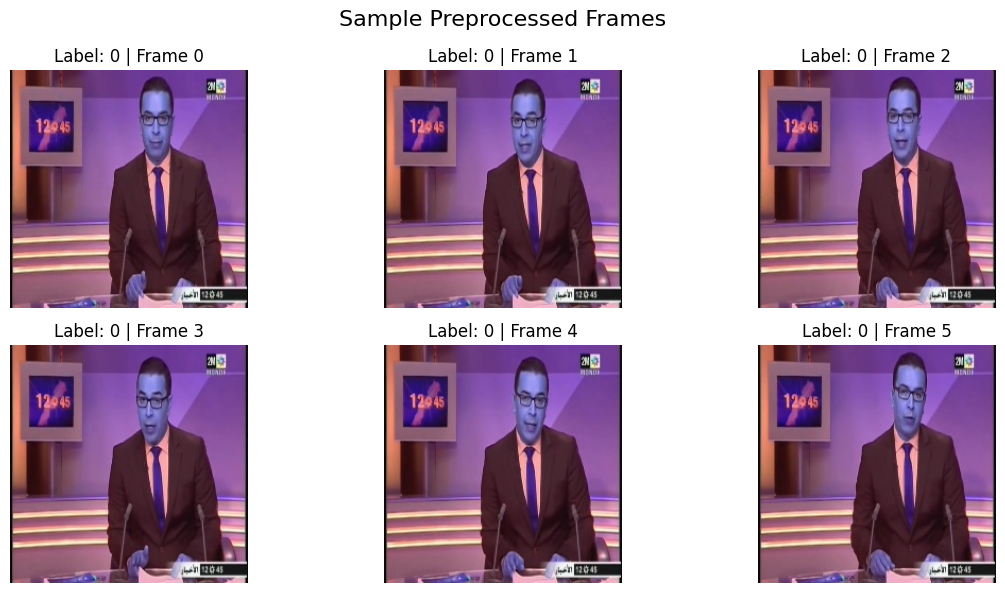

In [147]:
frames_tensor, label_tensor = train_dataset[0]

frames_np = frames_tensor.detach().cpu().numpy()
frames_np = np.transpose(frames_np, (0, 2, 3, 1))   # (T, C, H, W) -> (T, H, W, C)
frames_np = (frames_np * STD) + MEAN
frames_np = np.clip(frames_np, 0, 1)

plt.figure(figsize=(12, 6))
for i in range(min(6, len(frames_np))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(frames_np[i])
    plt.title(f"Label: {label_tensor.item()} | Frame {i}")
    plt.axis("off")

plt.suptitle("Sample Preprocessed Frames", fontsize=16)
plt.tight_layout()
plt.show()

### FF++ face crop extraction (MTCNN → MTCNN_FRAMES_ROOT)

Writes face crops to `MTCNN_FRAMES_ROOT` — a NEW path separate from the Haar-trained baseline's `FRAMES_ROOT`. This preserves the 86% baseline's reproducibility.

In [ ]:
all_rows = pd.concat([train_df, val_df, test_df], ignore_index=True)
if SMOKE_TEST:
    all_rows = all_rows.sample(n=min(50, len(all_rows)), random_state=42).reset_index(drop=True)

ffpp_stats = extract_batch(
    video_rows=all_rows.to_dict("records"),
    out_root=MTCNN_FRAMES_ROOT,
    num_frames=NUM_FRAMES,
    img_size=IMG_SIZE,
)
print("FF++ MTCNN face extraction complete:", ffpp_stats)


### Celeb-DF v2 face crops (for Phase 3 cross-dataset evaluation)

We pre-extract Celeb-DF face crops using the **same** MTCNN pipeline and same 16 frames / 224×224 crop as FF++, so that `06_evaluation.ipynb` can run zero-shot cross-dataset evaluation with an apples-to-apples preprocessing pipeline. The kaggle dataset is auto-downloaded if not present (requires `kaggle.json` credentials on the runtime — see project README).

In [ ]:
import os

CELEBDF_FRAMES.mkdir(parents=True, exist_ok=True)

if not any(CELEBDF_RAW_ROOT.rglob("*.mp4")):
    CELEBDF_RAW_ROOT.mkdir(parents=True, exist_ok=True)
    os.system(f'kaggle datasets download -d reubensuju/celeb-df-v2 -p "{CELEBDF_RAW_ROOT}" --unzip')
    print("Celeb-DF downloaded.")
else:
    print("Celeb-DF already present — skipping download.")

# Build Celeb-DF row list: label 0 for real (Celeb-real + YouTube-real), 1 for fake (Celeb-synthesis)
celeb_rows = []
for label_name, target, folder in [
    ("real", 0, "Celeb-real"),
    ("real", 0, "YouTube-real"),
    ("fake", 1, "Celeb-synthesis"),
]:
    folder_path = CELEBDF_RAW_ROOT / folder
    if not folder_path.exists():
        print(f"warn: {folder_path} not found — skipping")
        continue
    for vid in folder_path.rglob("*.mp4"):
        celeb_rows.append({
            "path": str(vid),
            "file": vid.name,
            "binary_label": label_name,
            "binary_target": target,
            "source_class": folder,
            "split": "test",
        })

if SMOKE_TEST:
    celeb_rows = celeb_rows[:20]

print(f"Celeb-DF videos queued: {len(celeb_rows)}")

celeb_stats = extract_batch(
    video_rows=celeb_rows,
    out_root=CELEBDF_FRAMES,
    num_frames=NUM_FRAMES,
    img_size=IMG_SIZE,
)
print("Celeb-DF MTCNN face extraction complete:", celeb_stats)


### Face crop sanity check

Spot-check 6 random extracted faces spanning real / fake to confirm MTCNN is producing usable crops (not e.g. background, hand, or blank frames).

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

crop_paths = list(MTCNN_FRAMES_ROOT.rglob("*.jpg"))
if not crop_paths:
    print("No MTCNN crops yet — run the FF++ extraction cell above first.")
else:
    random.seed(42)
    samples = random.sample(crop_paths, k=min(6, len(crop_paths)))

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for ax, p in zip(axes, samples):
        img = Image.open(p)
        label = p.parent.parent.name  # real/fake
        stem  = p.parent.name          # video stem
        ax.imshow(img); ax.set_title(f"{label}/{stem}", fontsize=7)
        ax.axis("off")
    plt.tight_layout(); plt.show()
